In [1]:
#Liberías e Importaciones

import pandas as pd
import numpy as np

#Visualización
import matplotlib.pyplot as plt
import seaborn as sns

#Modelos de Marchine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier

#train_test_split: Dividir el dataset en datos de entrenamiento y prueba de forma aleatoria y controlada
from sklearn.model_selection import train_test_split, cross_val_score

#StarndarScaler
#OrdinalEncoder: Codifique variables categoricas con orden real
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

#Clasificación
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)

In [2]:
#Carga de datos y lectura

df = pd.read_csv("student_habits_performance.csv")

df = df.drop(columns=['student_id'])

df.head()


,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [3]:
#Crear el target de clasificación
df['aprueba'] = (df['exam_score'] >=60).astype(int)

#Tratamiento de nulos
moda_educacion = df['parental_education_level'].mode()[0]
df['parental_education_level'] = df['parental_education_level'].fillna(moda_educacion)

# Encoding de variables categóricas
#diet_quality
oe_diet = OrdinalEncoder(categories=[['Poor', 'Fair', 'Good']])
df['diet_quality'] = oe_diet.fit_transform(df[['diet_quality']]).reshape(-1)

#internet_quality
oe_net = OrdinalEncoder(categories=[['Poor', 'Average', 'Good']])
df['internet_quality'] = oe_net.fit_transform(df[['internet_quality']]).reshape(-1)

#parental_education_level
oe_edu = OrdinalEncoder(categories=[['High School', 'Bachelor', 'Master']])
df['parental_education_level'] = oe_edu.fit_transform(df[['parental_education_level']]).reshape(-1)

#--Encoding binario para variables Yes/No
df['part_time_job'] = (df['part_time_job'] =='Yes').astype(int)
df['extracurricular_participation'] = (df['extracurricular_participation'] =='Yes').astype(int)

#--One Hot Encoding para gender (nominal, sin orden)

#Crear una columna binaria por cata categoría de genero
df = pd.get_dummies(df, columns=['gender'], drop_first=True, dtype=int)

df.head(5)

,age,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,aprueba,gender_Male,gender_Other
0,23,0.0,1.2,1.1,0,85.0,8.0,1.0,6,2.0,1.0,8,1,56.2,0,0,0
1,20,6.9,2.8,2.3,0,97.3,4.6,2.0,6,0.0,1.0,8,0,100.0,1,0,0
2,21,1.4,3.1,1.3,0,94.8,8.0,0.0,1,0.0,0.0,1,0,34.3,0,1,0
3,23,1.0,3.9,1.0,0,71.0,9.2,0.0,4,2.0,2.0,1,1,26.8,0,0,0
4,19,5.0,4.4,0.5,0,90.9,4.9,1.0,3,2.0,2.0,1,0,66.4,1,0,0


In [4]:
#Definición de features
features_reg = ['study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage',
                'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality',
                'mental_health_rating', 'extracurricular_participation', 'gender_Male', 'gender_Other']

In [5]:
#Separar los datos

X = df[features_reg]
y = df['aprueba']

#División estratificada
# Hay un desblanceamiento de 72% contra un 28%
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} estudiantes')
print(f'Prueba: {X_test.shape[0]} estudiantes')
print(f'Proporción de aprueba en train: {y_train.mean():.1%}')
print(f'Proporción de aprueba en test: {y_test.mean():.1%}')


Entrenamiento: 800 estudiantes
Prueba: 200 estudiantes
Proporción de aprueba en train: 72.0%
Proporción de aprueba en test: 72.0%


## Arboles de Decisión

In [6]:
#Entrenar el primer árbol (sin restricciones)

arbol_libre = DecisionTreeClassifier(criterion='gini', random_state=42)

#fit() analizar los 800 estudiantes de entrenamiento y contruya toda la estructura del árbol
arbol_libre.fit(X_train, y_train)

#Evaluamos sobre ambos conjuntos
acc_train_libre = accuracy_score(y_train, arbol_libre.predict(X_train))
acc_test_libre = accuracy_score(y_test, arbol_libre.predict(X_test))

print(f'Árbol sin restricción:')
print(f'Profundidad del arbol: {arbol_libre.get_depth()} niveles')
print(f'Número de hojas: {arbol_libre.get_n_leaves()}')
print(f' Accuracy en Entrenamiento: {acc_train_libre:.1%}')
print(f' Accuracy en Prueba: {acc_test_libre:.1%}')
print()
print(f'Diferencia train-test: {(acc_train_libre - acc_test_libre)*100:.1f} puntos porcentuales')
print(f' Esta diferencia grande indica OVERFITTING: el arbol memoizó el entrenamiento')

Árbol sin restricción:
Profundidad del arbol: 10 niveles
Número de hojas: 80
 Accuracy en Entrenamiento: 100.0%
 Accuracy en Prueba: 87.5%

Diferencia train-test: 12.5 puntos porcentuales
 Esta diferencia grande indica OVERFITTING: el arbol memoizó el entrenamiento


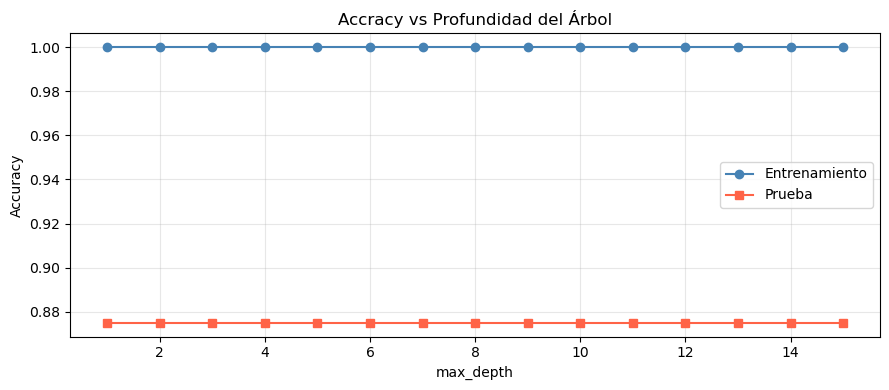

In [7]:
# Controlación del Overfiting con max_depth
# Probar varias profundidades del 1 al 15 y guardamos el accuracy en train y test para cada uno

profundidades = range(1, 16) #Valores de max_depth
acc_trains = []
acc_tests = []

for d in profundidades:
    arbol_d = DecisionTreeClassifier(max_depth=d, criterion='gini', random_state=42)
    arbol_d.fit(X_train, y_train)
    
    #Calcula el accuracy en ambos conjuntos y lo agrege a las listas
    acc_trains.append(accuracy_score(y_train, arbol_libre.predict(X_train)))
    acc_tests.append(accuracy_score(y_test, arbol_libre.predict(X_test)))
    

fig, ax = plt.subplots(figsize=(9, 4))

#Linea azul: accuracy en entreanmiento ( Siempre va a subir con más profundidad)
ax.plot(profundidades, acc_trains, marker='o', label='Entrenamiento', color='steelblue')

#Linea rojiza o naranja: accuracy en prueba (sube hasta un punto y luego baha o puede que se entanque por overfitting)
ax.plot(profundidades, acc_tests, marker='s', label='Prueba', color='tomato')

ax.set_title('Accracy vs Profundidad del Árbol')
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
mejor_depth = profundidades[acc_tests.index(max(acc_tests))]
print(f'Mejor max_depth según accuracy en prueba: {mejor_depth}')

#Entreanr el arbol definitivo con ese max_depth
arbol = DecisionTreeClassifier(
    max_depth=mejor_depth,
    criterion='gini',
    random_state=42
)
arbol.fit(X_train, y_train)

y_pred_arbol = arbol.predict(X_test)

acc_arbol = accuracy_score(y_test, y_pred_arbol)

print(f'Accuracy del arbol optimo en prueba: {acc_arbol:.1f}')
print(f'Profundidad real: {arbol.get_depth()} | Hojas: {arbol.get_n_leaves()}')

Mejor max_depth según accuracy en prueba: 1
Accuracy del arbol optimo en prueba: 0.8
Profundidad real: 1 | Hojas: 2


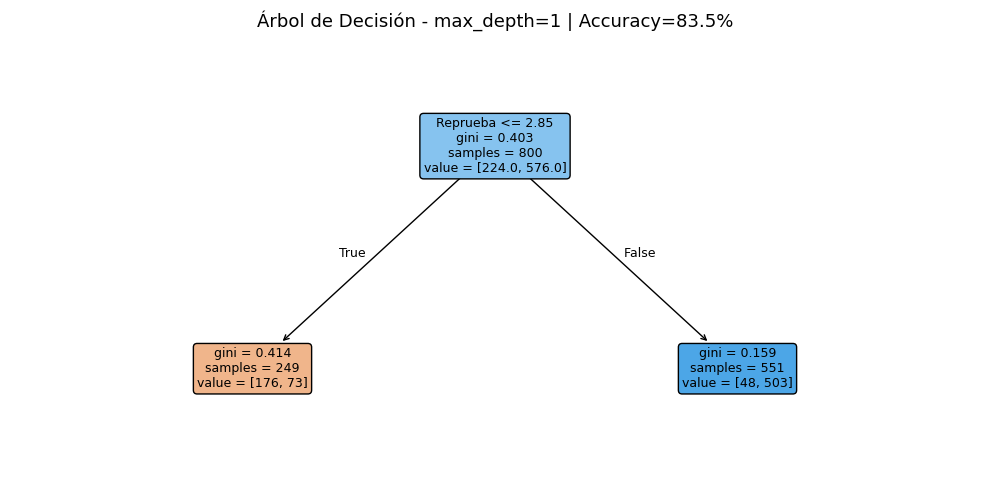

In [17]:
fig, ax = plt.subplots(figsize=(10,5))

plot_tree(
    arbol,
    feature_names=['Reprueba', 'Aprueba'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
    
)

ax.set_title(f'Árbol de Decisión - max_depth={mejor_depth} | Accuracy={acc_arbol:.1%}', fontsize=13)
plt.tight_layout()
plt.show()

## Random Forest


¿Por qué un árbol no es suficiente?

Fuentes de aleatoriedad: 

-Bootstrap (muestrteo con Reemplazo), temrino importante OOB (out-of-bag).

-Selección aleatoria de features en cada nodo. 


¿Que pasa con el Overfitting?

-Este se reduce ya que la diversidad entre arboles es la clave



## Entrenar el Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,              #¿Cuantos árboles construirá el bosque? (más = más estables, pero más lento)
    max_features='sqrt',             # 16 variables y su raiz es 4
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)

print(f'Accuracy Random Forest en Prueba: {acc_rf:.1%}')
print(f'Accuracy OBB (estimación interna): {rf.oob_score_:.1%}')
print()
print('OOB = Test accuracy -> El modelo generaliza bien y no hay data leakage')

Accuracy Random Forest en Prueba: 91.0%
Accuracy OBB (estimación interna): 89.6%

OBB = Test accuracy -> El modelo generaliza bien y no hay data leakage
